# 강원도 공간 데이터 EDA

전국 공간 EDA에서 확인한 주의점을 전제로, 강원도 내부의 영동권·영서권 및 시군구 단위 공간 차이를 분석한다.

전국 분석에서 이어받는 주의점은 다음과 같다.

- 강원도는 소방서·소방용수·임도·등산로 거리가 전국 최악이 아니므로, 단순 접근성 부족만으로 진화 지연을 설명하지 않는다.
- `산림지역_ratio`, 수종 세분류 비율은 직관과 다른 신호가 있으므로 원천 분류와 매칭 방식을 확인하기 전까지 핵심 위험 피처로 단정하지 않는다.
- `nearest_road_dist_km`는 전국 분석에서 직관과 반대 방향이 나타났으므로 실제 소방 접근성으로 바로 해석하지 않는다.
- 진화소요시간 분석은 유효 표본만 사용하며, 항상 유효 N을 함께 확인한다.

영동권 기준은 기존 강원도 날씨 EDA와 동일하게 `강릉, 속초, 동해, 삼척, 태백, 고성, 양양`으로 둔다.


In [11]:
# 라이브러리 및 한글 폰트 설정
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path
from scipy import stats

font_path = 'C:/Windows/Fonts/malgun.ttf'
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

sns.set_theme(
    style='whitegrid',
    font=font_name,
    rc={
        'font.family': font_name,
        'font.sans-serif': [font_name],
        'axes.unicode_minus': False
    }
)
plt.rcParams['font.family'] = font_name
plt.rcParams['font.sans-serif'] = [font_name]
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', None)

REGION_ORDER = ['영동권', '영서권']
REGION_PALETTE = {'영동권': '#E45756', '영서권': '#4C78A8'}

print('matplotlib 한글 폰트 설정 완료:', plt.rcParams['font.family'])


matplotlib 한글 폰트 설정 완료: ['Malgun Gothic']


In [12]:
# 데이터 경로 및 캐시 로드
BASE_DIR = Path('D:/farm-system-public-02')
EDA_DIR = BASE_DIR / 'jsw' / 'EDA'
CACHE_PATH = EDA_DIR / 'fire_spatial_features.csv'

merged_df = pd.read_csv(CACHE_PATH, encoding='utf-8-sig')
gangwon_df = merged_df[merged_df['is_gangwon'] == True].copy()

print(f'공간 피처 캐시 형태: {merged_df.shape}')
print(f'강원도 분석 대상 형태: {gangwon_df.shape}')
print(f'강원도 산불 비율: {len(gangwon_df) / len(merged_df) * 100:.2f}%')


공간 피처 캐시 형태: (25036, 60)
강원도 분석 대상 형태: (4139, 60)
강원도 산불 비율: 16.53%


## 1. 강원도 시군구 정규화 및 분석 피처 생성

원천 데이터에는 `강릉시`와 `강릉`처럼 같은 시군구가 다른 표기로 함께 존재한다.
먼저 18개 강원도 시군구 이름으로 정규화한 뒤, 영동권/영서권을 분리한다.


In [13]:
# 시군구 정규화 및 분석 보조 피처 생성
YEONGDONG_BASES = {'강릉', '속초', '동해', '삼척', '태백', '고성', '양양'}
BASE_TO_CANON = {
    '강릉': '강릉시',
    '고성': '고성군',
    '동해': '동해시',
    '삼척': '삼척시',
    '속초': '속초시',
    '양양': '양양군',
    '태백': '태백시',
    '춘천': '춘천시',
    '원주': '원주시',
    '홍천': '홍천군',
    '횡성': '횡성군',
    '영월': '영월군',
    '평창': '평창군',
    '정선': '정선군',
    '철원': '철원군',
    '화천': '화천군',
    '양구': '양구군',
    '인제': '인제군',
}

def normalize_city(value):
    text = str(value).strip()
    for suffix in ['특별자치시', '자치시', '시', '군']:
        if text.endswith(suffix):
            text = text[:-len(suffix)]
            break
    return BASE_TO_CANON.get(text, str(value).strip())

gangwon_df['city_norm'] = gangwon_df['발생지역시군구명'].map(normalize_city)
gangwon_df['city_base'] = gangwon_df['city_norm'].str.replace(r'(시|군)$', '', regex=True)
gangwon_df['gangwon_region'] = np.where(gangwon_df['city_base'].isin(YEONGDONG_BASES), '영동권', '영서권')

if {'사면방향_sin', '사면방향_cos'}.issubset(gangwon_df.columns):
    gangwon_df['aspect_deg'] = np.degrees(np.arctan2(gangwon_df['사면방향_sin'], gangwon_df['사면방향_cos'])) % 360
    aspect_bins = [0, 22.5, 67.5, 112.5, 157.5, 202.5, 247.5, 292.5, 337.5, 360]
    aspect_labels = ['북(N)', '북동(NE)', '동(E)', '남동(SE)', '남(S)', '남서(SW)', '서(W)', '북서(NW)', '북(N)']
    gangwon_df['aspect_8dir'] = pd.cut(
        gangwon_df['aspect_deg'],
        bins=aspect_bins,
        labels=aspect_labels,
        include_lowest=True,
        ordered=False
    ).astype(str)

gangwon_df['west_southwest_aspect'] = gangwon_df.get('aspect_8dir', pd.Series('', index=gangwon_df.index)).isin(['서(W)', '남서(SW)'])

suppression_col = '진화소요시간(HH)' if '진화소요시간(HH)' in gangwon_df.columns else '진화소요시간'
gangwon_df['_suppression_hours'] = pd.to_numeric(gangwon_df[suppression_col], errors='coerce')
gangwon_df['_suppression_valid'] = (gangwon_df['_suppression_hours'] > 0) & gangwon_df['_suppression_hours'].notna()
gangwon_df['_large_fire_12h'] = np.where(
    gangwon_df['_suppression_valid'],
    gangwon_df['_suppression_hours'] >= 12,
    np.nan
)

gangwon_df['_damage_ha'] = pd.to_numeric(gangwon_df.get('피해면적(ha)', np.nan), errors='coerce')
gangwon_df['_large_damage_10ha'] = np.where(gangwon_df['_damage_ha'].notna(), gangwon_df['_damage_ha'] >= 10, np.nan)
gangwon_df['remote_unavailable'] = gangwon_df['nearest_facility_remote'].astype(str).eq('불가능')

dist_vars = [
    'nearest_station_dist_km',
    'nearest_water_dist_km',
    'nearest_facility_dist_km',
    'nearest_trail_dist_km',
    'nearest_road_dist_km'
]
dist_vars = [c for c in dist_vars if c in gangwon_df.columns]
for col in dist_vars:
    gangwon_df[f'{col}_gw_pct'] = gangwon_df[col].rank(pct=True)

gangwon_df['access_burden_gw'] = gangwon_df[[f'{c}_gw_pct' for c in dist_vars]].mean(axis=1)
gangwon_df['access_grade_gw'] = pd.qcut(
    gangwon_df['access_burden_gw'],
    q=[0, 1/3, 2/3, 1],
    labels=['접근 우수', '접근 보통', '접근 취약'],
    duplicates='drop'
)

thresholds = {
    '고고도': ('고도(m)', gangwon_df['고도(m)'].quantile(0.75)),
    '급경사': ('경사도(도)', gangwon_df['경사도(도)'].quantile(0.75)),
    '고산림비율': ('산림지역_ratio', gangwon_df['산림지역_ratio'].quantile(0.75)),
    '접근취약': ('access_burden_gw', gangwon_df['access_burden_gw'].quantile(0.75)),
}
gangwon_df['high_altitude_gw'] = gangwon_df['고도(m)'] >= thresholds['고고도'][1]
gangwon_df['high_slope_gw'] = gangwon_df['경사도(도)'] >= thresholds['급경사'][1]
gangwon_df['high_forest_ratio_gw'] = gangwon_df['산림지역_ratio'] >= thresholds['고산림비율'][1]
gangwon_df['poor_access_gw'] = gangwon_df['access_burden_gw'] >= thresholds['접근취약'][1]

score_flags = [
    'high_altitude_gw',
    'high_slope_gw',
    'high_forest_ratio_gw',
    'poor_access_gw',
    'remote_unavailable',
    'west_southwest_aspect',
]
gangwon_df['gw_compound_spatial_score'] = gangwon_df[score_flags].sum(axis=1)
gangwon_df['gw_compound_score_band'] = pd.cut(
    gangwon_df['gw_compound_spatial_score'],
    bins=[-0.1, 1, 2, 3, 6],
    labels=['0-1개', '2개', '3개', '4개 이상']
)

unknown_cities = sorted(set(gangwon_df['city_norm']) - set(BASE_TO_CANON.values()))
print('정규화 실패 후보:', unknown_cities)
print('\n--- 정규화 시군구별 건수 ---')
print(gangwon_df['city_norm'].value_counts().to_string())
print('\n--- 영동/영서 표본 수 ---')
print(gangwon_df['gangwon_region'].value_counts().reindex(REGION_ORDER).to_string())
print('\n--- 진화소요시간 유효 표본 ---')
print(gangwon_df.groupby('gangwon_region')['_suppression_valid'].agg(['sum', 'count']).reindex(REGION_ORDER))


정규화 실패 후보: []

--- 정규화 시군구별 건수 ---
city_norm
동해시    495
양양군    369
평창군    368
원주시    333
홍천군    326
강릉시    294
영월군    274
횡성군    265
철원군    258
삼척시    222
화천군    200
춘천시    182
고성군    144
정선군    140
인제군    131
태백시     69
양구군     53
속초시     16

--- 영동/영서 표본 수 ---
gangwon_region
영동권    1609
영서권    2530

--- 진화소요시간 유효 표본 ---
                sum  count
gangwon_region            
영동권             269   1609
영서권             463   2530


**결과 메모**

- 시군구 정규화 실패 후보는 없었고, 강원도 18개 시군구로 정상 정리되었다.
- 영동권 표본은 **1,609건**, 영서권 표본은 **2,530건**이다.
- 진화소요시간 유효 표본은 영동권 **269건**, 영서권 **463건**으로, 진화시간 해석에서는 전체 표본보다 유효 N이 훨씬 작다는 점을 계속 주의해야 한다.


## 2. 영동권 vs 영서권 공간 조건 비교

전국 분석에서 확인한 “강원도는 접근성이 전국 최악이 아니다”라는 결론을 강원도 내부로 가져와, 영동권과 영서권의 지형·시설·방향성 차이를 비교한다.


 권역  전체 N  시군 수  진화시간 유효 N  평균 진화시간(h)  중앙 진화시간(h)  12h 이상 비율(%)  평균 피해면적(ha)  10ha 이상 피해 비율(%)   고도 중앙값  경사도 중앙값  서/남서 사면 비율(%)  소방서 거리 평균(km)  소방용수 거리 평균(km)  임도 거리 평균(km)  원격제어 불가능(%)  산림지역 중앙값  접근부담 평균
영동권  1609     7        269      3.4985      1.3333        8.1784      16.2665            1.6159  55.4054   4.7867        44.0646         4.7172          0.8910        4.8284      87.1970    0.3543   0.4713
영서권  2530    11        463      2.3552      1.4833        4.5356       0.3745            0.3557 287.6157   6.8818        22.6087         6.3732          1.3272        4.0637      75.7312    0.4020   0.5184


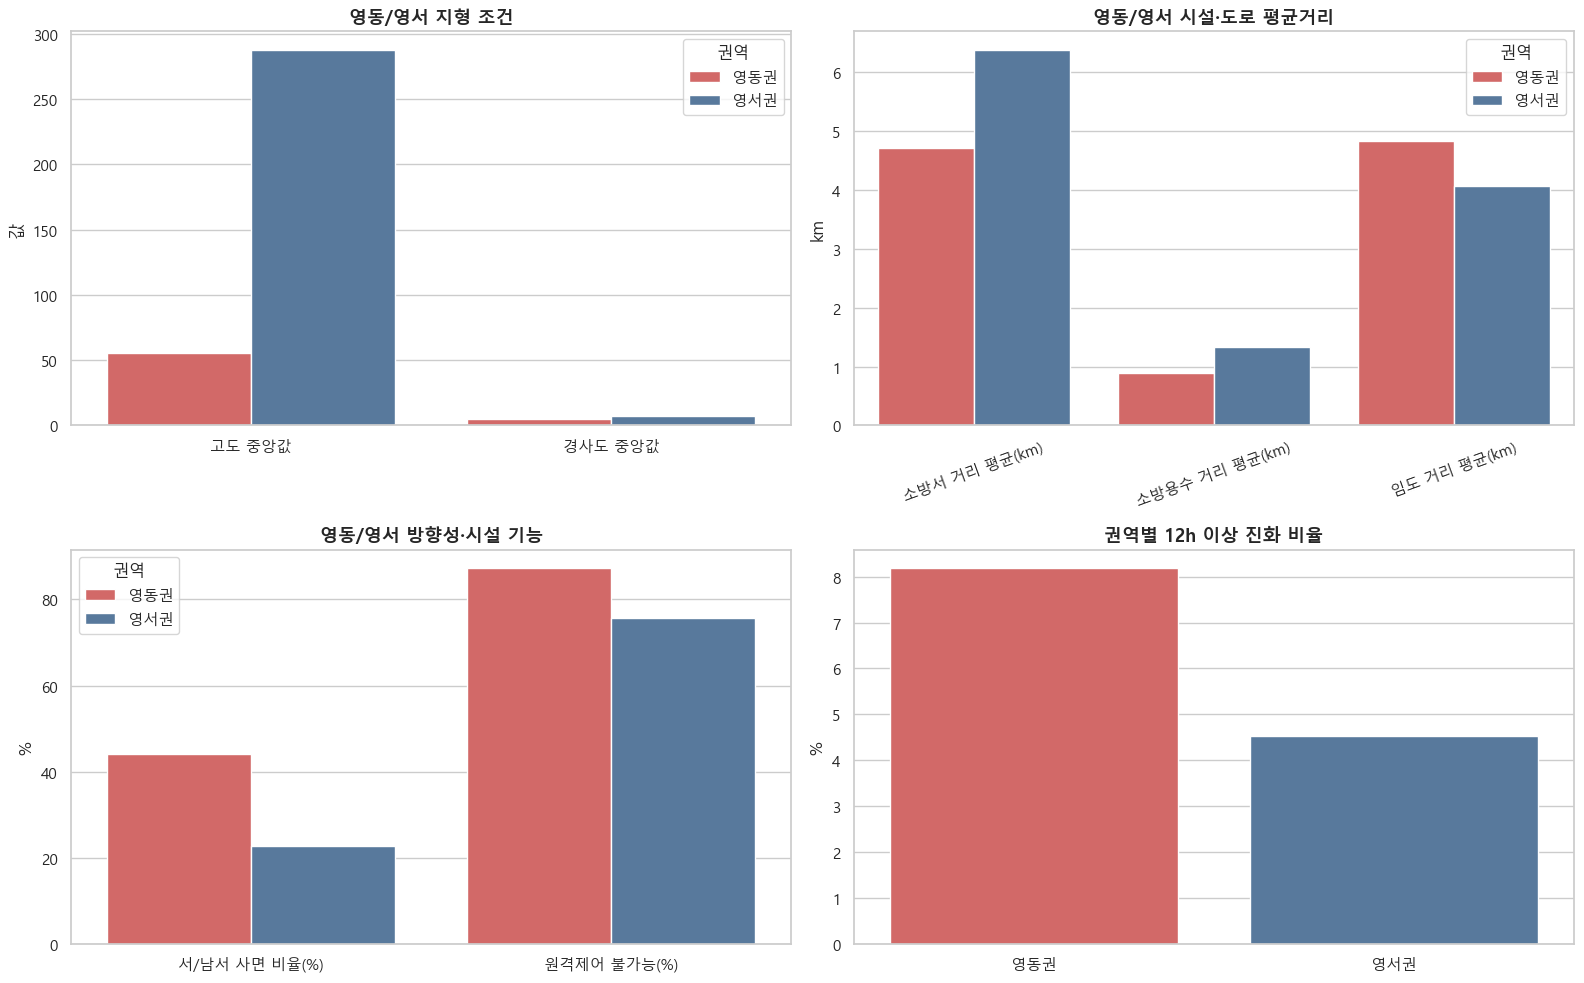

In [14]:
# 영동/영서 권역별 요약
def region_summary(df):
    rows = []
    for region, g in df.groupby('gangwon_region'):
        valid = g[g['_suppression_valid']]
        rows.append({
            '권역': region,
            '전체 N': len(g),
            '시군 수': g['city_norm'].nunique(),
            '진화시간 유효 N': len(valid),
            '평균 진화시간(h)': valid['_suppression_hours'].mean(),
            '중앙 진화시간(h)': valid['_suppression_hours'].median(),
            '12h 이상 비율(%)': valid['_large_fire_12h'].mean() * 100,
            '평균 피해면적(ha)': g['_damage_ha'].mean(),
            '10ha 이상 피해 비율(%)': g['_large_damage_10ha'].mean() * 100,
            '고도 중앙값': g['고도(m)'].median(),
            '경사도 중앙값': g['경사도(도)'].median(),
            '서/남서 사면 비율(%)': g['west_southwest_aspect'].mean() * 100,
            '소방서 거리 평균(km)': g['nearest_station_dist_km'].mean(),
            '소방용수 거리 평균(km)': g['nearest_water_dist_km'].mean(),
            '임도 거리 평균(km)': g['nearest_road_dist_km'].mean(),
            '원격제어 불가능(%)': g['remote_unavailable'].mean() * 100,
            '산림지역 중앙값': g['산림지역_ratio'].median(),
            '접근부담 평균': g['access_burden_gw'].mean(),
        })
    return pd.DataFrame(rows).set_index('권역').reindex(REGION_ORDER).reset_index()

reg_summary = region_summary(gangwon_df)
print(reg_summary.round(4).to_string(index=False))

plot_reg_melt = reg_summary.melt(
    id_vars=['권역'],
    value_vars=['고도 중앙값', '경사도 중앙값', '소방서 거리 평균(km)', '소방용수 거리 평균(km)', '임도 거리 평균(km)', '서/남서 사면 비율(%)', '원격제어 불가능(%)'],
    var_name='변수',
    value_name='값',
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.barplot(
    data=plot_reg_melt[plot_reg_melt['변수'].isin(['고도 중앙값', '경사도 중앙값'])],
    x='변수', y='값', hue='권역', hue_order=REGION_ORDER, palette=REGION_PALETTE, ax=axes[0, 0]
)
axes[0, 0].set_title('영동/영서 지형 조건', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('값')

sns.barplot(
    data=plot_reg_melt[plot_reg_melt['변수'].isin(['소방서 거리 평균(km)', '소방용수 거리 평균(km)', '임도 거리 평균(km)'])],
    x='변수', y='값', hue='권역', hue_order=REGION_ORDER, palette=REGION_PALETTE, ax=axes[0, 1]
)
axes[0, 1].set_title('영동/영서 시설·도로 평균거리', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('km')
axes[0, 1].tick_params(axis='x', rotation=20)

sns.barplot(
    data=plot_reg_melt[plot_reg_melt['변수'].isin(['서/남서 사면 비율(%)', '원격제어 불가능(%)'])],
    x='변수', y='값', hue='권역', hue_order=REGION_ORDER, palette=REGION_PALETTE, ax=axes[1, 0]
)
axes[1, 0].set_title('영동/영서 방향성·시설 기능', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('')
axes[1, 0].set_ylabel('%')

sns.barplot(
    data=reg_summary,
    x='권역', y='12h 이상 비율(%)', hue='권역',
    order=REGION_ORDER, hue_order=REGION_ORDER, palette=REGION_PALETTE, legend=False, ax=axes[1, 1]
)
axes[1, 1].set_title('권역별 12h 이상 진화 비율', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('')
axes[1, 1].set_ylabel('%')

plt.tight_layout()
plt.show()


In [15]:
# 영동/영서 주요 변수 Welch t-test
test_vars = [
    '고도(m)',
    '경사도(도)',
    '산림지역_ratio',
    'nearest_station_dist_km',
    'nearest_water_dist_km',
    'nearest_facility_dist_km',
    'nearest_road_dist_km',
    'nearest_trail_dist_km',
    'access_burden_gw',
    '_suppression_hours',
    '_damage_ha',
]

test_rows = []
for var in test_vars:
    if var == '_suppression_hours':
        y = gangwon_df.loc[(gangwon_df['gangwon_region'] == '영동권') & gangwon_df['_suppression_valid'], var].dropna()
        s = gangwon_df.loc[(gangwon_df['gangwon_region'] == '영서권') & gangwon_df['_suppression_valid'], var].dropna()
    else:
        y = gangwon_df.loc[gangwon_df['gangwon_region'] == '영동권', var].dropna()
        s = gangwon_df.loc[gangwon_df['gangwon_region'] == '영서권', var].dropna()
    t, p = stats.ttest_ind(y, s, equal_var=False, nan_policy='omit')
    test_rows.append({
        '변수': var,
        '영동 유효 N': len(y),
        '영서 유효 N': len(s),
        '영동 평균': y.mean(),
        '영서 평균': s.mean(),
        '영동-영서 차이': y.mean() - s.mean(),
        't': t,
        'p': p,
    })

region_test_summary = pd.DataFrame(test_rows)
print(region_test_summary.round(6).to_string(index=False))


                      변수  영동 유효 N  영서 유효 N      영동 평균      영서 평균    영동-영서 차이          t        p
                   고도(m)     1609     2530 130.161165 328.523140 -198.361975 -33.257608 0.000000
                  경사도(도)     1609     2530   6.103288   8.387664   -2.284376 -11.983014 0.000000
              산림지역_ratio     1609     2530   0.440138   0.444343   -0.004205  -0.351685 0.725096
 nearest_station_dist_km     1609     2530   4.717219   6.373182   -1.655963 -11.582868 0.000000
   nearest_water_dist_km     1609     2530   0.891025   1.327198   -0.436173  -8.246819 0.000000
nearest_facility_dist_km     1609     2530  13.638786  12.809772    0.829014   4.139858 0.000036
    nearest_road_dist_km     1609     2530   4.828387   4.063679    0.764708   7.645059 0.000000
   nearest_trail_dist_km     1609     2530   1.009254   2.376251   -1.366998 -26.219320 0.000000
        access_burden_gw     1609     2530   0.471318   0.518439   -0.047121 -11.797834 0.000000
      _suppression_hours      

<!-- gangwon-spatial-analysis:region -->

**결과 및 플롯 이미지 분석**

- 영동권은 영서권보다 고도와 경사도가 낮다. 고도 중앙값은 영동권 **55.41m**, 영서권 **287.62m**로 크게 차이 난다. 따라서 강원도 내부에서는 “고산악 지형이라서 영동권 진화가 길다”는 단순 설명이 맞지 않는다.
- 영동권은 소방서와 소방용수, 등산로에는 더 가깝다. 접근부담 평균도 영동권 **0.4713**, 영서권 **0.5184**로 영동권이 더 양호하다.
- 그런데 12h 이상 진화 비율은 영동권 **8.18%**, 영서권 **4.54%**로 영동권이 약 1.8배 높다. 평균 진화시간도 영동권 **3.50h**, 영서권 **2.36h**로 유의미하게 높다($p=0.023$).
- 시각적으로 가장 뚜렷한 차이는 서/남서 사면 비율과 산불소화시설 원격제어 불가능 비율이다. 영동권은 서/남서 사면 비율이 **44.06%**로 영서권 **22.61%**의 약 2배이고, 원격제어 불가능도 **87.20%**로 높다.
- 이 패턴은 앞선 날씨 EDA의 서풍·남서풍 계열 양간지풍 결과와 연결된다. 영동권은 접근성이 나빠서 위험한 것이 아니라, 서/남서 방향성 지형과 시설 기능 제약 위에 강풍·저습 기상이 겹치면서 진화 난도가 커지는 구조로 해석된다.


## 3. 시군구별 공간 취약 프로파일

강원도 내부에서도 영동권 전체 평균만으로는 부족하므로, 시군구별 표본 수와 진화 결과, 공간 피처를 함께 확인한다.


In [16]:
# 시군구별 요약
city_rows = []
for city, g in gangwon_df.groupby('city_norm'):
    valid = g[g['_suppression_valid']]
    city_rows.append({
        '시군구': city,
        '권역': g['gangwon_region'].iloc[0],
        'N': len(g),
        '진화 유효 N': len(valid),
        '평균 진화시간(h)': valid['_suppression_hours'].mean(),
        '중앙 진화시간(h)': valid['_suppression_hours'].median(),
        '12h 이상 비율(%)': valid['_large_fire_12h'].mean() * 100,
        '피해면적 평균(ha)': g['_damage_ha'].mean(),
        '10ha 이상 피해 비율(%)': g['_large_damage_10ha'].mean() * 100,
        '고도 중앙값': g['고도(m)'].median(),
        '경사도 중앙값': g['경사도(도)'].median(),
        '서/남서 사면 비율(%)': g['west_southwest_aspect'].mean() * 100,
        '소방서 거리 평균(km)': g['nearest_station_dist_km'].mean(),
        '소방용수 거리 평균(km)': g['nearest_water_dist_km'].mean(),
        '임도 거리 평균(km)': g['nearest_road_dist_km'].mean(),
        '원격제어 불가능(%)': g['remote_unavailable'].mean() * 100,
        '산림지역 중앙값': g['산림지역_ratio'].median(),
        '접근부담 평균': g['access_burden_gw'].mean(),
        '복합점수 평균': g['gw_compound_spatial_score'].mean(),
    })

city_summary = pd.DataFrame(city_rows).sort_values('N', ascending=False)
print(city_summary.round(4).to_string(index=False))


시군구  권역   N  진화 유효 N  평균 진화시간(h)  중앙 진화시간(h)  12h 이상 비율(%)  피해면적 평균(ha)  10ha 이상 피해 비율(%)   고도 중앙값  경사도 중앙값  서/남서 사면 비율(%)  소방서 거리 평균(km)  소방용수 거리 평균(km)  임도 거리 평균(km)  원격제어 불가능(%)  산림지역 중앙값  접근부담 평균  복합점수 평균
동해시 영동권 495       18      5.6639      0.9250       11.1111       4.6039            0.4040  55.4054   4.7867        58.3838         2.9248          0.3528        4.9808      97.1717    0.4543   0.4652   1.9475
양양군 영동권 369       31      3.2382      1.1667        6.4516       3.2326            0.8130  33.6595   3.7501        46.0705         7.0077          0.6687        4.5463     100.0000    0.0000   0.5007   1.8076
평창군 영서권 368       34      1.5564      1.4500        0.0000       0.0405            0.0000 524.7123  10.8579        24.4565         3.4941          1.3575        2.5360     100.0000    0.6723   0.4682   3.3940
원주시 영서권 333       49      1.6099      0.9167        2.0408       0.8267            0.3003 136.4527   5.3200        13.8138         5.1962          1.0003        5.7

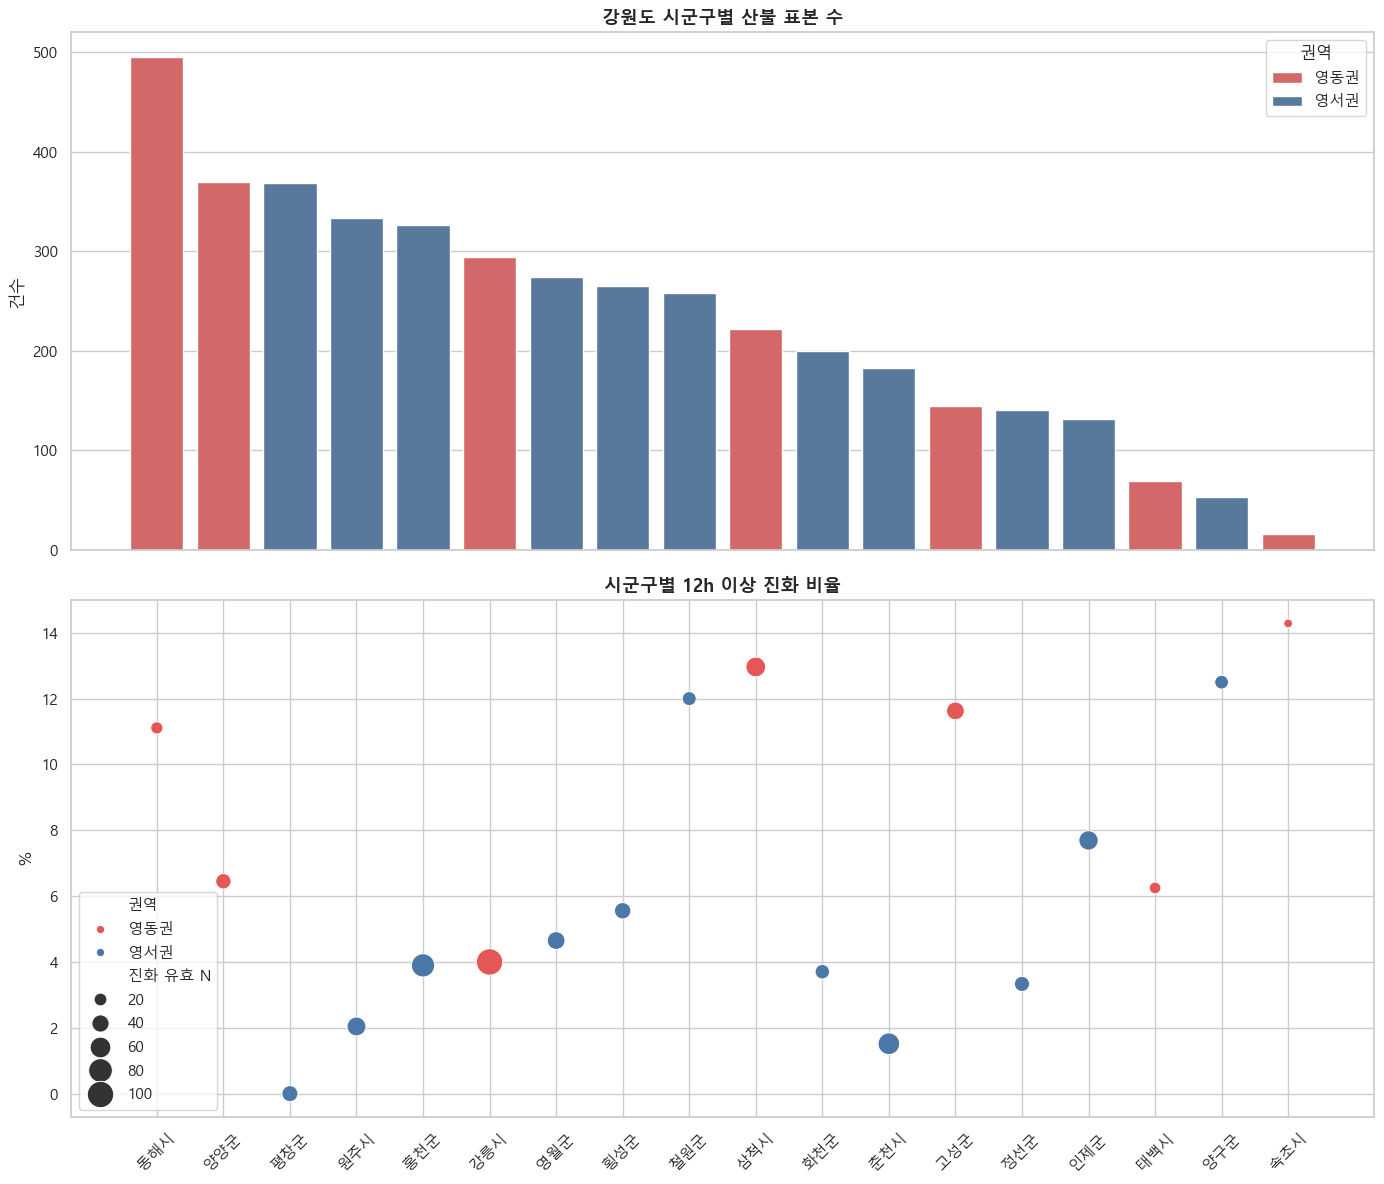

In [17]:
# 시군구별 표본 수와 12h 이상 진화 비율
city_order = city_summary.sort_values('N', ascending=False)['시군구'].tolist()

fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)
sns.barplot(
    data=city_summary,
    x='시군구', y='N', hue='권역',
    order=city_order, hue_order=REGION_ORDER, dodge=False, palette=REGION_PALETTE, ax=axes[0]
)
axes[0].set_title('강원도 시군구별 산불 표본 수', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('건수')

sns.scatterplot(
    data=city_summary,
    x='시군구', y='12h 이상 비율(%)',
    size='진화 유효 N', hue='권역',
    hue_order=REGION_ORDER, sizes=(40, 360), palette=REGION_PALETTE, ax=axes[1]
)
axes[1].set_title('시군구별 12h 이상 진화 비율', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


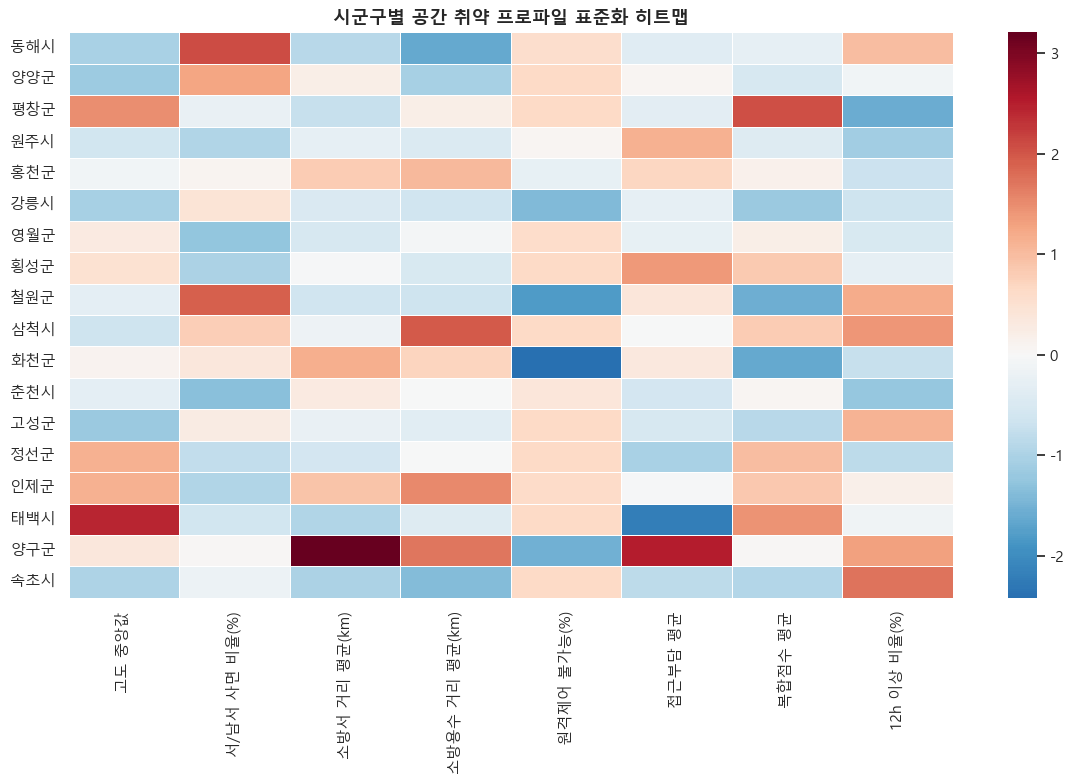

In [18]:
# 시군구별 공간 취약 프로파일 표준화 히트맵
heat_cols = [
    '고도 중앙값',
    '서/남서 사면 비율(%)',
    '소방서 거리 평균(km)',
    '소방용수 거리 평균(km)',
    '원격제어 불가능(%)',
    '접근부담 평균',
    '복합점수 평균',
    '12h 이상 비율(%)',
]
heat_df = city_summary.set_index('시군구')[heat_cols].copy()
heat_scaled = (heat_df - heat_df.mean()) / heat_df.std(ddof=0)

plt.figure(figsize=(12, 8))
sns.heatmap(heat_scaled, cmap='RdBu_r', center=0, linewidths=0.5)
plt.title('시군구별 공간 취약 프로파일 표준화 히트맵', fontsize=13, fontweight='bold')
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()


<!-- gangwon-spatial-analysis:city -->

**결과 및 플롯 이미지 분석**

- 표본 수는 동해시 **495건**, 양양군 **369건**, 평창군 **368건**, 원주시 **333건**, 홍천군 **326건** 순으로 많다. 영동권에서는 동해·양양·강릉·삼척이 핵심 관찰 대상이다.
- 12h 이상 진화 비율은 속초시 **14.29%**, 삼척시 **12.96%**, 양구군 **12.50%**, 철원군 **12.00%**, 고성군 **11.63%**, 동해시 **11.11%**가 높다. 다만 속초는 진화 유효 N이 7건뿐이므로 안정적 고위험 결론으로 쓰기 어렵다.
- 시각적으로 영동권 고위험 후보는 동해시·삼척시·고성군이다. 이들은 영동권 색상으로 표시되면서 12h 이상 비율이 높고, 삼척·고성은 피해면적 평균도 크게 튄다.
- 히트맵에서는 동해시가 서/남서 사면 비율이 매우 높고, 삼척시는 소방용수 거리와 12h 이상 비율이 동시에 높다. 고성군은 12h 이상 비율은 높지만 접근부담이 극단적으로 나쁜 유형은 아니다.
- 철원군과 양구군은 영서권이지만 12h 이상 비율이 높다. 이들은 양간지풍 축과 다른 별도 고위험 유형일 수 있으므로, 강원도 모델에서는 영동권 플래그만으로 모든 장기 진화 위험을 설명하면 안 된다.


## 4. 사면방향과 접근성 조건 내 진화 차이

전국 분석에서 강원도는 서향·남서향 사면 쏠림이 있었고, 날씨 EDA에서는 서풍·남서풍 계열 바람이 핵심으로 나타났다.
여기서는 영동/영서 내부에서 사면방향 분포와 접근성 등급별 진화 결과를 함께 본다.


--- 접근성 등급별 진화 결과 ---
 권역 접근성 등급  전체 N  진화 유효 N  평균 진화시간(h)  12h 이상 비율(%)  평균 피해면적(ha)
영동권  접근 우수   604       76      2.8268        6.5789      24.7036
영동권  접근 보통   687      109      1.9742        4.5872       0.9359
영동권  접근 취약   318       84      6.0843       14.2857      33.3613
영서권  접근 우수   776       84      1.8694        3.5714       0.1414
영서권  접근 보통   692      120      2.1546        3.3333       0.1107
영서권  접근 취약  1062      259      2.6057        5.4054       0.7166


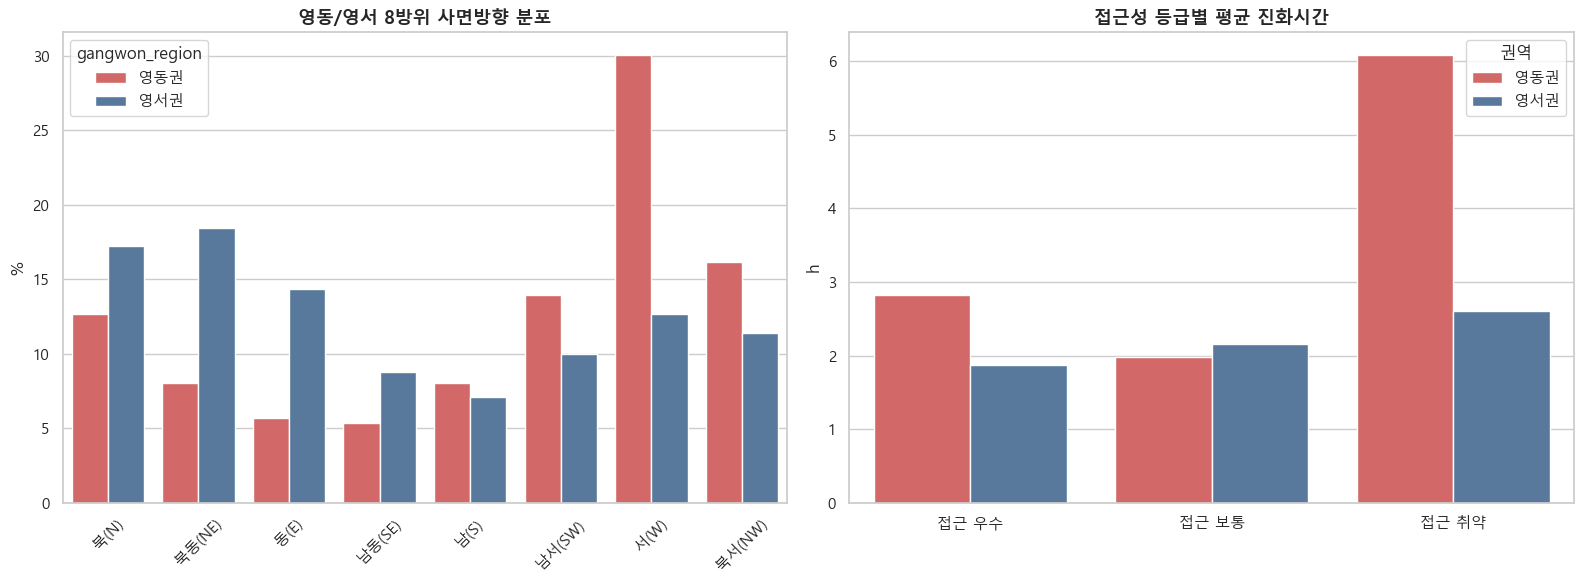

In [19]:
# 사면방향 분포와 접근성 등급별 진화 결과
aspect_order = ['북(N)', '북동(NE)', '동(E)', '남동(SE)', '남(S)', '남서(SW)', '서(W)', '북서(NW)']
aspect_table = (
    gangwon_df
    .groupby('gangwon_region')['aspect_8dir']
    .value_counts(normalize=True)
    .mul(100)
    .rename('비율')
    .reset_index()
)

access_rows = []
for (region, grade), g in gangwon_df.groupby(['gangwon_region', 'access_grade_gw'], observed=True):
    valid = g[g['_suppression_valid']]
    access_rows.append({
        '권역': region,
        '접근성 등급': str(grade),
        '전체 N': len(g),
        '진화 유효 N': len(valid),
        '평균 진화시간(h)': valid['_suppression_hours'].mean(),
        '12h 이상 비율(%)': valid['_large_fire_12h'].mean() * 100,
        '평균 피해면적(ha)': g['_damage_ha'].mean(),
    })
access_summary = pd.DataFrame(access_rows)
print('--- 접근성 등급별 진화 결과 ---')
print(access_summary.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(
    data=aspect_table,
    x='aspect_8dir', y='비율', hue='gangwon_region',
    order=aspect_order, hue_order=REGION_ORDER, palette=REGION_PALETTE, ax=axes[0]
)
axes[0].set_title('영동/영서 8방위 사면방향 분포', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=45)

grade_order = ['접근 우수', '접근 보통', '접근 취약']
sns.barplot(
    data=access_summary,
    x='접근성 등급', y='평균 진화시간(h)', hue='권역',
    order=grade_order, hue_order=REGION_ORDER, palette=REGION_PALETTE, ax=axes[1]
)
axes[1].set_title('접근성 등급별 평균 진화시간', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('h')
plt.tight_layout()
plt.show()


<!-- gangwon-spatial-analysis:aspect-access -->

**결과 및 플롯 이미지 분석**

- 영동권의 사면방향은 서향(W)이 약 **30%**로 압도적이며, 남서향(SW)까지 합치면 **44.06%**다. 영서권은 북·북동·동 방향 비율이 상대적으로 높아 분포 형태가 뚜렷하게 다르다.
- 접근성 등급별 플롯에서 영동권 `접근 취약` 구간의 평균 진화시간이 **6.08h**로 크게 튄다. 같은 `접근 취약` 구간의 영서권 평균은 **2.61h**다.
- 영동권은 `접근 우수`에서도 평균 진화시간이 **2.83h**로 영서권 **1.87h**보다 높다. 즉 영동권 진화 지연은 접근성 취약 구간에서 증폭되지만, 접근성이 좋은 곳에서도 완전히 사라지지 않는다.
- 해석상 핵심은 “서/남서 사면 + 양간지풍 계열 바람 + 일부 접근/시설 기능 취약”의 결합이다. 접근성 단독 피처보다 사면방향 및 영동권 플래그와의 상호작용이 더 중요해 보인다.


## 5. 복합 공간 위험 점수와 토지피복 주의점

강원도 내부 상위 25% 기준으로 고도, 경사, 산림비율, 접근취약을 플래그화하고 원격제어 불가능, 서/남서 사면을 더해 탐색용 복합 공간 위험 점수를 만든다.
동시에 전국 분석에서 주의 대상으로 남긴 토지피복·수종 피처를 영동/영서 내부에서도 확인한다.


--- 복합 공간 위험 점수별 결과 ---
 권역  복합점수  전체 N  권역 내 비율(%)  진화 유효 N  평균 진화시간(h)  12h 이상 비율(%)
영동권  0-1개   572     35.5500       74      2.1387        4.0541
영동권    2개   675     41.9515       67      2.6067        7.4627
영동권    3개   226     14.0460       55      5.7921       14.5455
영동권 4개 이상   136      8.4525       73      3.9674        8.2192
영서권  0-1개   845     33.3992       59      2.2274        5.0847
영서권    2개   755     29.8419      106      2.2887        3.7736
영서권    3개   432     17.0751      108      2.8745        7.4074
영서권 4개 이상   498     19.6838      190      2.1368        3.1579

--- 토지피복/수종 평균 비율 ---
                산림지역_ratio  침엽수림_ratio  활엽수림_ratio  혼효림_ratio
gangwon_region                                               
영동권                0.44014     0.00013     0.00029    0.00007
영서권                0.44434     0.01081     0.01166    0.00602

--- 토지피복/수종 중앙값 ---
                산림지역_ratio  침엽수림_ratio  활엽수림_ratio  혼효림_ratio
gangwon_region                                         

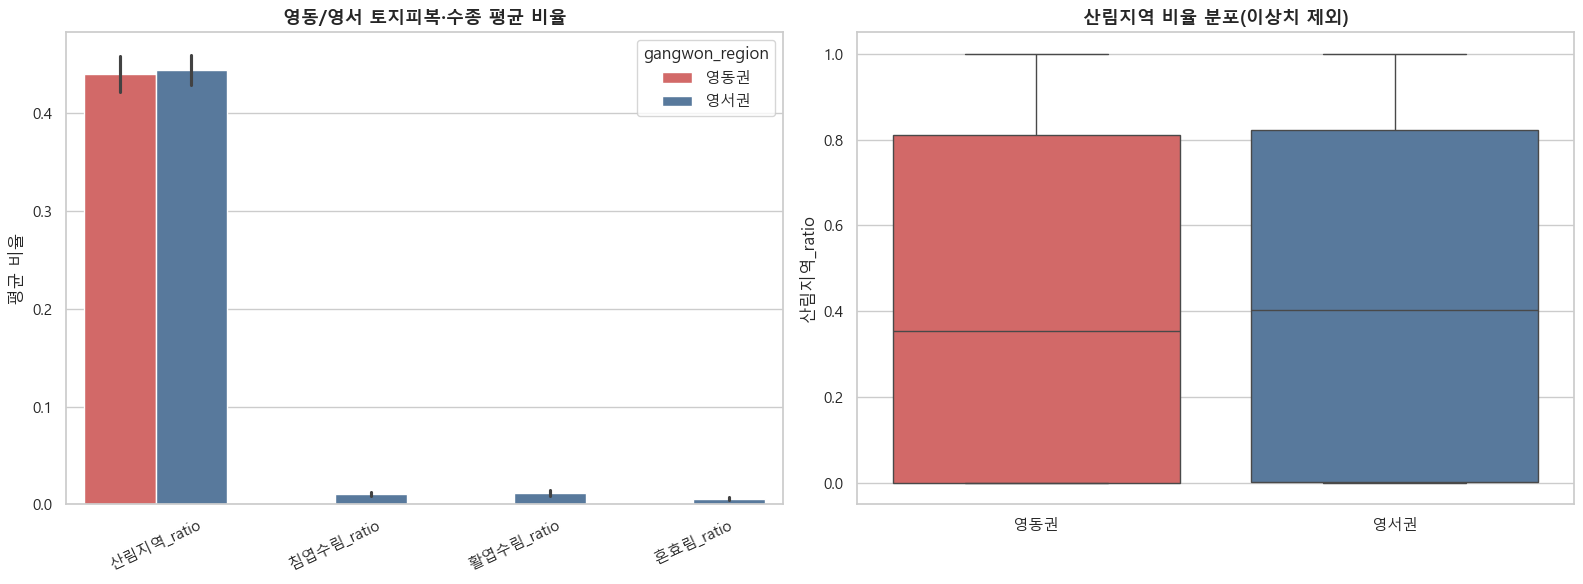

In [20]:
# 복합 공간 위험 점수와 토지피복/수종 확인
score_rows = []
for (region, band), g in gangwon_df.groupby(['gangwon_region', 'gw_compound_score_band'], observed=True):
    valid = g[g['_suppression_valid']]
    score_rows.append({
        '권역': region,
        '복합점수': str(band),
        '전체 N': len(g),
        '권역 내 비율(%)': len(g) / (gangwon_df['gangwon_region'] == region).sum() * 100,
        '진화 유효 N': len(valid),
        '평균 진화시간(h)': valid['_suppression_hours'].mean(),
        '12h 이상 비율(%)': valid['_large_fire_12h'].mean() * 100,
    })

score_summary = pd.DataFrame(score_rows)
print('--- 복합 공간 위험 점수별 결과 ---')
print(score_summary.round(4).to_string(index=False))

lc_cols = ['산림지역_ratio', '침엽수림_ratio', '활엽수림_ratio', '혼효림_ratio']
print('\n--- 토지피복/수종 평균 비율 ---')
print(gangwon_df.groupby('gangwon_region')[lc_cols].mean().reindex(REGION_ORDER).round(5).to_string())
print('\n--- 토지피복/수종 중앙값 ---')
print(gangwon_df.groupby('gangwon_region')[lc_cols].median().reindex(REGION_ORDER).round(5).to_string())

lc_melt = gangwon_df.melt(id_vars=['gangwon_region'], value_vars=lc_cols, var_name='피처', value_name='비율')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(
    data=lc_melt,
    x='피처', y='비율', hue='gangwon_region',
    hue_order=REGION_ORDER, palette=REGION_PALETTE, ax=axes[0]
)
axes[0].set_title('영동/영서 토지피복·수종 평균 비율', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('평균 비율')
axes[0].tick_params(axis='x', rotation=25)

sns.boxplot(
    data=gangwon_df,
    x='gangwon_region', y='산림지역_ratio', hue='gangwon_region',
    order=REGION_ORDER, hue_order=REGION_ORDER,
    palette=REGION_PALETTE, legend=False, ax=axes[1], showfliers=False
)
axes[1].set_title('산림지역 비율 분포(이상치 제외)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('산림지역_ratio')
plt.tight_layout()
plt.show()


<!-- gangwon-spatial-analysis:compound-landcover -->

**결과 및 플롯 이미지 분석**

- 복합 공간 점수는 영동권에서 `3개` 구간이 가장 강한 신호를 보였다. 해당 구간의 평균 진화시간은 **5.79h**, 12h 이상 비율은 **14.55%**로 영동권 내에서 가장 높다.
- 반면 `4개 이상` 구간은 12h 이상 비율이 **8.22%**로 낮아진다. 이는 전국 분석과 마찬가지로 단순히 점수가 높을수록 위험이 증가하는 구조가 아니라, 특정 조합이 위험을 키우는 비선형 패턴임을 의미한다.
- 토지피복 플롯에서 `산림지역_ratio`는 영동권과 영서권의 평균이 거의 비슷하고, 수종 세분류 비율은 전반적으로 매우 낮다. 특히 영동권의 수종 세분류는 막대가 거의 바닥에 붙어 있어 원천 분류/매칭 이슈 가능성이 계속 남는다.
- 따라서 강원도 공간 모델링에서도 `산림지역_ratio`는 보조 피처로는 사용할 수 있지만, 수종 세분류는 원천 GPKG 분류 확인 전까지 핵심 피처로 쓰기 어렵다.


## 6. 강원도 공간 EDA 정리

- 강원도 내부에서 영동권은 영서권보다 고도·경사·접근부담이 낮거나 양호한데도 평균 진화시간과 12h 이상 비율이 높다.
- 영동권의 핵심 공간 신호는 **서/남서 사면 쏠림**, **산불소화시설 원격제어 불가능 비율**, 그리고 `접근 취약` 구간에서의 진화시간 급증이다.
- 시군구 단위에서는 동해시·삼척시·고성군이 영동권 주요 공간 고위험 후보로 보인다. 속초시는 12h 이상 비율은 높지만 진화 유효 N이 작아 해석을 제한한다.
- 철원군·양구군은 영서권 안에서도 12h 이상 비율이 높은 예외적 지역이다. 강원도 모델에서는 영동권 플래그 외에 별도의 북부 내륙 취약 유형도 확인할 필요가 있다.
- 전국 분석에서 남긴 주의점은 강원도 내부에서도 유지된다. `nearest_road_dist_km`, 수종 세분류, 일부 토지피복 비율은 원천 데이터 정의와 매칭 방식을 확인한 뒤 모델링 피처로 채택해야 한다.
- 다음 단계는 날씨 EDA의 강풍·저습·양간지풍 피처와 이 공간 피처를 결합해, `영동권 × 서/남서 사면 × 접근취약 × 원격제어 불가능` 같은 상호작용 후보를 모델링용 피처로 검토하는 것이다.


<!-- gangwon-spatial-deep:start -->
## 7. 심화 분석: 핵심 공간 조합의 단계별 위험 누적

앞선 강원도 공간 EDA에서 가장 중요한 후보는 `영동권 × 서/남서 사면 × 접근취약 × 원격제어 불가능` 조합이었다.
이 조합이 실제로 결과 지표를 단계적으로 악화시키는지 확인한다.

단, 마지막 핵심 조합은 진화소요시간 유효 표본이 작을 수 있으므로 검정 결과보다 방향성과 후보성에 초점을 둔다.


                조합  전체 N  진화 유효 N  평균 진화시간(h)  중앙 진화시간(h)  12h 이상 비율(%)  피해면적 평균(ha)  피해면적 중앙값(ha)  피해면적 P95(ha)  10ha 이상 피해 비율(%)
            전체 강원도  4139      732      2.7753      1.4167        5.8743       6.5523           0.0         0.500            0.8456
               영동권  1609      269      3.4985      1.3333        8.1784      16.2665           0.0         0.700            1.6159
          영동권+서/남서   709       78      4.0759      1.0833       10.2564      25.0370           0.0         0.200            1.2694
     영동권+서/남서+접근취약   133       28      7.2452      1.4333       14.2857      29.1699           0.0         0.580            3.0075
영동권+서/남서+접근취약+원격불가   116       26      7.7769      1.6250       15.3846      33.4443           0.0         1.125            3.4483

핵심 조합 vs 나머지 Welch t-test: t=1.5791, p=0.12682, N=26 vs 706


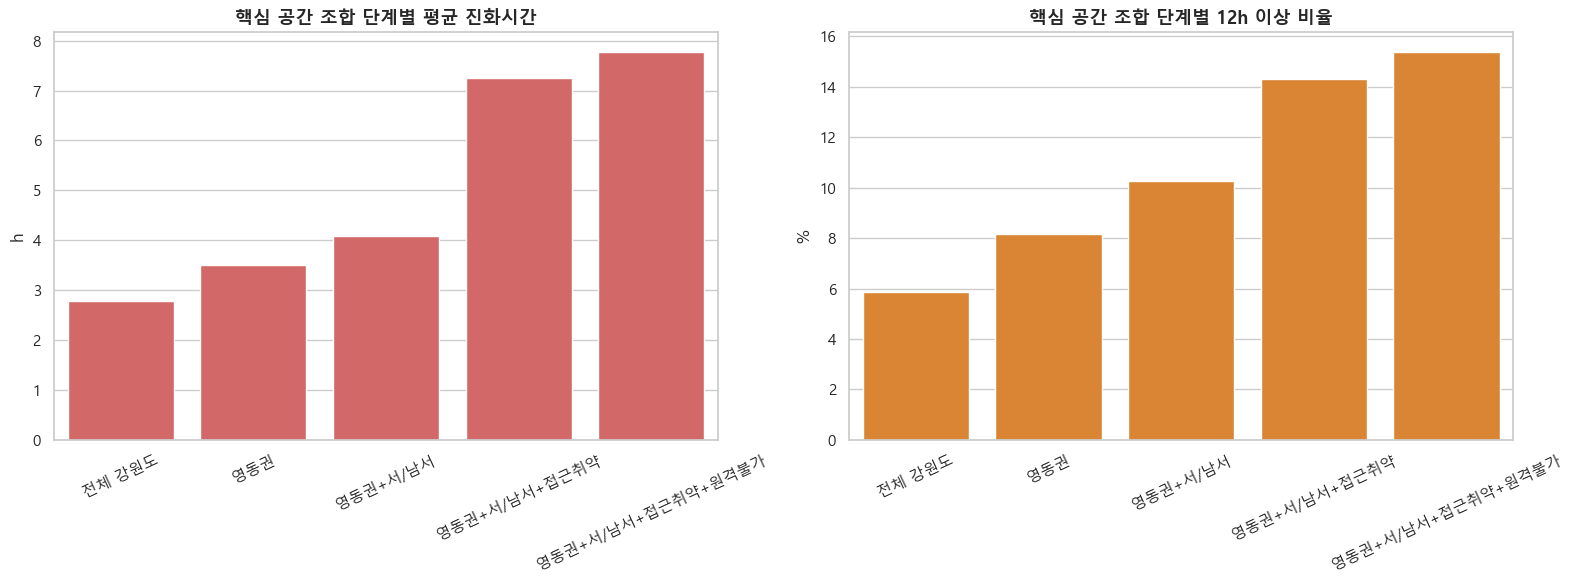

In [21]:
# 심화 분석 보조 변수
gangwon_df['aspect_group'] = np.where(gangwon_df['aspect_8dir'].isin(['서(W)', '남서(SW)']), '서/남서 사면', '기타 사면')
gangwon_df['is_yeongdong'] = gangwon_df['gangwon_region'].eq('영동권')
gangwon_df['access_vulnerable'] = gangwon_df['access_grade_gw'].astype(str).eq('접근 취약')
gangwon_df['west_southwest_aspect'] = gangwon_df['aspect_group'].eq('서/남서 사면')
gangwon_df['remote_unavailable'] = gangwon_df['nearest_facility_remote'].astype(str).eq('불가능')
gangwon_df['dry_season'] = gangwon_df['월'].isin([11, 12, 1, 2, 3, 4, 5])
gangwon_df['spring'] = gangwon_df['월'].isin([3, 4, 5])

interaction_flags = ['is_yeongdong', 'west_southwest_aspect', 'access_vulnerable', 'remote_unavailable']
gangwon_df['interaction_score'] = gangwon_df[interaction_flags].sum(axis=1)
gangwon_df['core_combo'] = gangwon_df[interaction_flags].all(axis=1)
gangwon_df['yd_ws_combo'] = gangwon_df['is_yeongdong'] & gangwon_df['west_southwest_aspect']
gangwon_df['yd_ws_access_combo'] = gangwon_df['yd_ws_combo'] & gangwon_df['access_vulnerable']

def outcome_summary(g):
    valid = g[g['_suppression_valid']]
    return {
        '전체 N': len(g),
        '진화 유효 N': len(valid),
        '평균 진화시간(h)': valid['_suppression_hours'].mean(),
        '중앙 진화시간(h)': valid['_suppression_hours'].median(),
        '12h 이상 비율(%)': valid['_large_fire_12h'].mean() * 100,
        '피해면적 평균(ha)': g['_damage_ha'].mean(),
        '피해면적 중앙값(ha)': g['_damage_ha'].median(),
        '피해면적 P95(ha)': g['_damage_ha'].quantile(0.95),
        '10ha 이상 피해 비율(%)': g['_large_damage_10ha'].mean() * 100,
    }

step_defs = [
    ('전체 강원도', pd.Series(True, index=gangwon_df.index)),
    ('영동권', gangwon_df['is_yeongdong']),
    ('영동권+서/남서', gangwon_df['yd_ws_combo']),
    ('영동권+서/남서+접근취약', gangwon_df['yd_ws_access_combo']),
    ('영동권+서/남서+접근취약+원격불가', gangwon_df['core_combo']),
]

step_rows = []
for label, mask in step_defs:
    row = {'조합': label}
    row.update(outcome_summary(gangwon_df[mask]))
    step_rows.append(row)

step_summary = pd.DataFrame(step_rows)
print(step_summary.round(4).to_string(index=False))

core = gangwon_df[gangwon_df['core_combo'] & gangwon_df['_suppression_valid']]['_suppression_hours'].dropna()
other = gangwon_df[(~gangwon_df['core_combo']) & gangwon_df['_suppression_valid']]['_suppression_hours'].dropna()
if len(core) > 1 and len(other) > 1:
    t_core, p_core = stats.ttest_ind(core, other, equal_var=False, nan_policy='omit')
    print(f'\n핵심 조합 vs 나머지 Welch t-test: t={t_core:.4f}, p={p_core:.6g}, N={len(core)} vs {len(other)}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
order = step_summary['조합'].tolist()
sns.barplot(data=step_summary, x='조합', y='평균 진화시간(h)', order=order, color='#E45756', ax=axes[0])
axes[0].set_title('핵심 공간 조합 단계별 평균 진화시간', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('h')
axes[0].tick_params(axis='x', rotation=25)

sns.barplot(data=step_summary, x='조합', y='12h 이상 비율(%)', order=order, color='#F58518', ax=axes[1])
axes[1].set_title('핵심 공간 조합 단계별 12h 이상 비율', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()


<!-- gangwon-spatial-deep-analysis:core-combo -->

**결과 및 플롯 이미지 분석**

- `전체 강원도 → 영동권 → 영동권+서/남서 사면 → 영동권+서/남서 사면+접근취약 → 원격제어 불가능 추가`로 조건을 누적할수록 평균 진화시간과 12h 이상 비율이 거의 단조롭게 상승했다.
- 평균 진화시간은 전체 강원도 **2.78h**에서 최종 핵심 조합 **7.78h**까지 증가했고, 12h 이상 비율도 **5.87% → 15.38%**로 높아졌다.
- 다만 최종 핵심 조합의 진화 유효 N은 **26건**으로 작고, Welch t-test는 $p=0.127$로 통계적으로 충분히 안정적이지 않다. 따라서 이 조합은 확정 규칙이 아니라 모델링 상호작용 후보로 보는 것이 안전하다.
- 플롯상 위험 증가는 `영동권+서/남서`에서 한 번, `접근취약`이 추가될 때 한 번 더 크게 커진다. 원격제어 불가능은 마지막 증폭 요인으로 보인다.


## 8. 4요소 상호작용 매트릭스

권역, 사면방향 그룹, 접근성 등급, 산불소화시설 원격제어 가능 여부를 함께 묶어 조합별 결과를 확인한다.
진화 유효 N이 10건 미만인 조합은 히트맵 해석에서 제외한다.


gangwon_region aspect_group access_grade_gw  remote_unavailable  전체 N  진화 유효 N  평균 진화시간(h)  중앙 진화시간(h)  12h 이상 비율(%)  피해면적 평균(ha)  피해면적 중앙값(ha)  피해면적 P95(ha)  10ha 이상 피해 비율(%) 원격제어
           영동권      서/남서 사면           접근 보통               False    42       13      2.9846      1.0833       15.3846       1.6876           0.0        0.2925            4.7619   가능
           영동권      서/남서 사면           접근 우수                True   224       13      3.9513      1.0833       15.3846      59.6711           0.0        0.0085            0.8929  불가능
           영동권      서/남서 사면           접근 취약                True   116       26      7.7769      1.6250       15.3846      33.4443           0.0        1.1250            3.4483  불가능
           영동권        기타 사면           접근 취약                True   167       52      5.3276      2.2667       13.4615      31.8616           0.0        2.0000            2.9940  불가능
           영서권        기타 사면           접근 우수               False   105       13      2.2359     

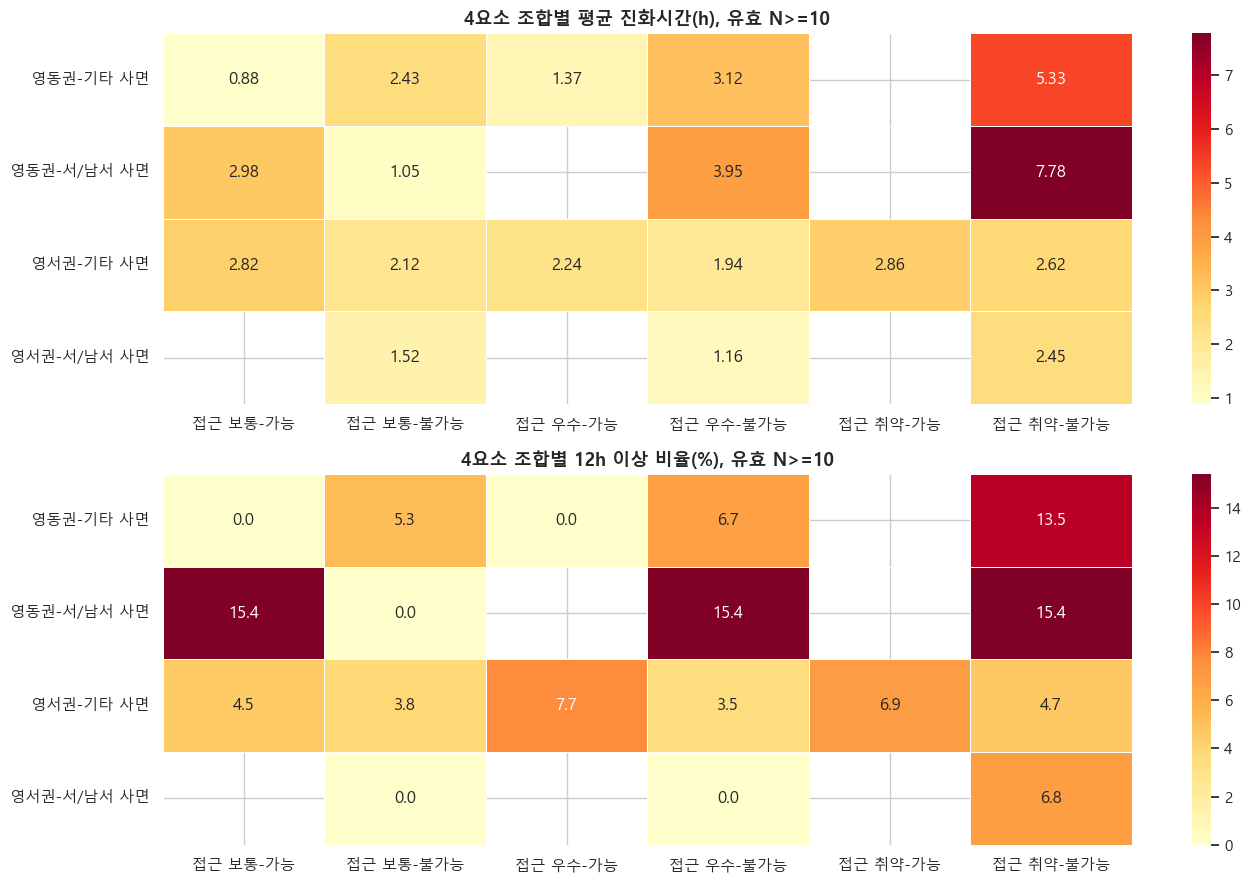

In [22]:
# 4요소 조합별 결과
def summarize_by(df, cols):
    rows = []
    for keys, g in df.groupby(cols, observed=True):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = {col: key for col, key in zip(cols, keys)}
        row.update(outcome_summary(g))
        rows.append(row)
    return pd.DataFrame(rows)

combo_summary = summarize_by(gangwon_df, ['gangwon_region', 'aspect_group', 'access_grade_gw', 'remote_unavailable'])
combo_summary['원격제어'] = np.where(combo_summary['remote_unavailable'], '불가능', '가능')
combo_display = combo_summary[combo_summary['진화 유효 N'] >= 10].sort_values('12h 이상 비율(%)', ascending=False)
print(combo_display.round(4).to_string(index=False))

pivot_mean = combo_display.pivot_table(
    index=['gangwon_region', 'aspect_group'],
    columns=['access_grade_gw', '원격제어'],
    values='평균 진화시간(h)',
    observed=True,
)
pivot_large = combo_display.pivot_table(
    index=['gangwon_region', 'aspect_group'],
    columns=['access_grade_gw', '원격제어'],
    values='12h 이상 비율(%)',
    observed=True,
)

fig, axes = plt.subplots(2, 1, figsize=(14, 9))
sns.heatmap(pivot_mean, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5, ax=axes[0])
axes[0].set_title('4요소 조합별 평균 진화시간(h), 유효 N>=10', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('')
sns.heatmap(pivot_large, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5, ax=axes[1])
axes[1].set_title('4요소 조합별 12h 이상 비율(%), 유효 N>=10', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()


<!-- gangwon-spatial-deep-analysis:interaction -->

**결과 및 플롯 이미지 분석**

- 평균 진화시간 히트맵에서 가장 진한 구간은 `영동권-서/남서 사면-접근 취약-원격제어 불가능`이며, 평균 **7.78h**다.
- `영동권-기타 사면-접근 취약-원격제어 불가능`도 평균 **5.33h**, 12h 이상 비율 **13.5%**로 높다. 즉 서/남서 사면이 핵심 축이지만, 영동권 접근취약 자체도 위험을 키운다.
- `영동권-서/남서 사면`은 접근성이 우수하거나 보통이어도 일부 조합에서 12h 이상 비율이 **15.4%**로 높다. 다만 유효 N이 10~13건인 조합도 있어 비율이 튈 수 있다.
- 영서권은 조합별 진화시간이 대체로 1~3h 범위에 모여 있고, 영동권 접근취약 조합처럼 진한 위험 블록이 넓게 형성되지는 않는다.
- 모델링 관점에서는 `영동권`, `서/남서 사면`, `접근취약`, `원격제어 불가능`의 단일 피처보다 2-way 또는 3-way 상호작용이 더 중요할 수 있다.


## 9. 계절과 공간 조건의 결합

강원도 날씨 EDA에서 봄철과 양간지풍이 중요했으므로, 공간 조건이 계절에 따라 다르게 작동하는지 확인한다.
계절은 봄철(3~5월), 기타 건조기(11~2월), 비건조기(6~10월)로 나눈다.


         계절구분 gangwon_region aspect_group  전체 N  진화 유효 N  평균 진화시간(h)  중앙 진화시간(h)  12h 이상 비율(%)  피해면적 평균(ha)  피해면적 중앙값(ha)  피해면적 P95(ha)  10ha 이상 피해 비율(%)
기타 건조기(11-2월)            영동권      서/남서 사면   411       21      1.7516      0.6500        9.5238       0.0747           0.0         0.000            0.2433
기타 건조기(11-2월)            영서권        기타 사면   839       93      1.9197      1.4167        3.2258       0.0799           0.0         0.200            0.1192
기타 건조기(11-2월)            영동권        기타 사면   649       88      1.9295      1.1583        2.2727       0.2491           0.0         0.360            0.4622
기타 건조기(11-2월)            영서권      서/남서 사면   177       14      1.2202      1.4167        0.0000       0.0249           0.0         0.100            0.0000
     봄철(3-5월)            영동권        기타 사면   220       88      4.2286      1.5500       10.2273      37.5115           0.0        16.848            6.3636
     봄철(3-5월)            영동권      서/남서 사면   100       49      5.0531      1.

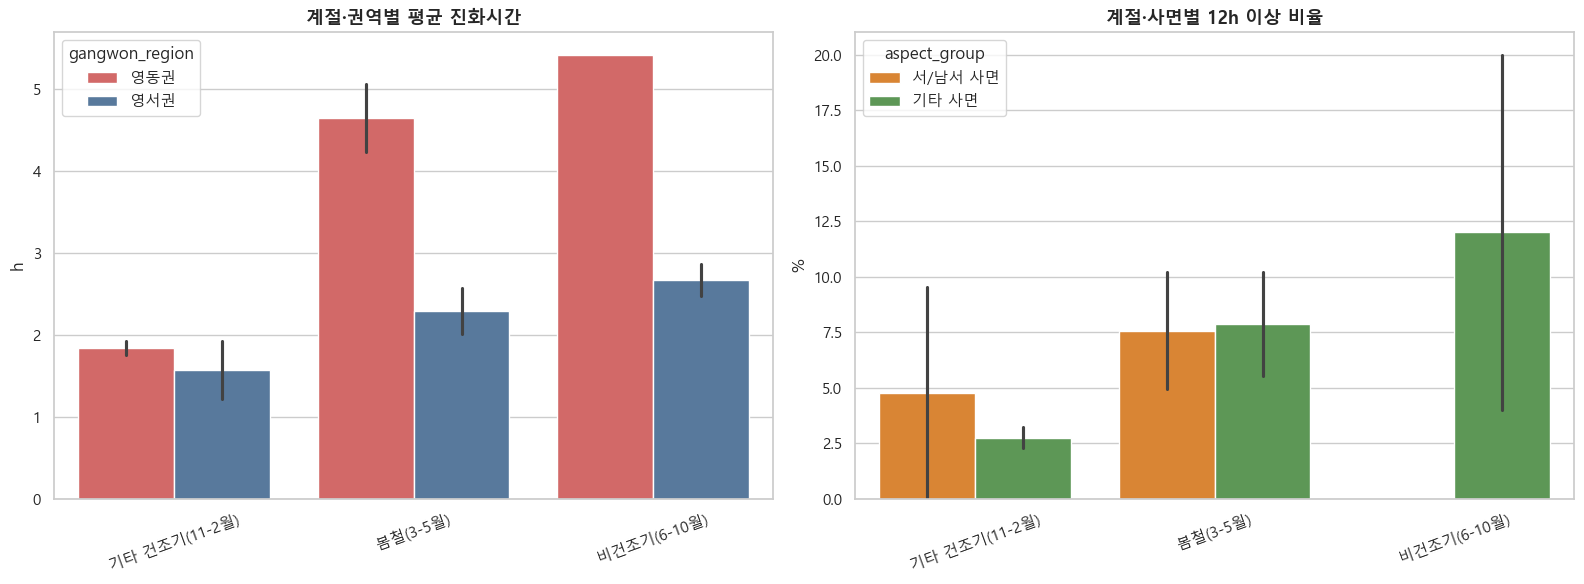

In [23]:
# 계절 x 권역 x 사면 요약
season_df = gangwon_df.copy()
season_df['계절구분'] = np.select(
    [season_df['spring'], season_df['dry_season']],
    ['봄철(3-5월)', '기타 건조기(11-2월)'],
    default='비건조기(6-10월)'
)

season_summary = summarize_by(season_df, ['계절구분', 'gangwon_region', 'aspect_group'])
season_display = season_summary[season_summary['진화 유효 N'] >= 10].sort_values(
    ['계절구분', '12h 이상 비율(%)'],
    ascending=[True, False]
)
print(season_display.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(
    data=season_display,
    x='계절구분', y='평균 진화시간(h)', hue='gangwon_region',
    hue_order=REGION_ORDER, palette=REGION_PALETTE, ax=axes[0]
)
axes[0].set_title('계절·권역별 평균 진화시간', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('h')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(
    data=season_display,
    x='계절구분', y='12h 이상 비율(%)', hue='aspect_group',
    palette={'서/남서 사면': '#F58518', '기타 사면': '#54A24B'}, ax=axes[1]
)
axes[1].set_title('계절·사면별 12h 이상 비율', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()


<!-- gangwon-spatial-deep-analysis:season -->

**결과 및 플롯 이미지 분석**

- 봄철에는 영동권 평균 진화시간이 약 **4~5h**로 영서권 **2h대**보다 뚜렷하게 높다. 봄철 영동권은 서/남서 사면과 기타 사면 모두 12h 이상 비율이 약 **10%** 수준으로 올라간다.
- 기타 건조기(11~2월)는 영동권 서/남서 사면의 12h 이상 비율이 **9.52%**로 높지만, 평균 진화시간은 봄철보다 낮다. 피해면적 평균도 작아 대형 확산보다 일부 장기 진화 사례 중심으로 보인다.
- 비건조기(6~10월)는 영동권 기타 사면의 12h 이상 비율이 **20%**로 높게 보이지만, 진화 유효 N이 15건뿐이므로 일반화는 제한한다.
- 계절 플롯의 오차막대가 큰 구간은 표본 수가 작거나 아웃라이어가 강하다는 신호다. 따라서 계절 결합 피처는 봄철 영동권을 중심으로 사용하고, 비건조기 패턴은 보조 탐색으로 남기는 것이 안전하다.


## 10. 안정 표본 기준 시군구 고위험 후보

시군구별 12h 이상 비율은 유효 N이 작으면 크게 흔들릴 수 있다.
진화소요시간 유효 N이 20건 이상인 시군구만 대상으로 평균 진화시간과 12h 이상 비율을 함께 본다.


city_norm gangwon_region  전체 N  진화 유효 N  평균 진화시간(h)  중앙 진화시간(h)  12h 이상 비율(%)  피해면적 평균(ha)  피해면적 중앙값(ha)  피해면적 P95(ha)  10ha 이상 피해 비율(%)
      삼척시            영동권   222       54      4.9988      2.1833       12.9630      78.9269           0.0        1.6425            2.2523
      양구군            영서권    53       24      3.6729      2.2083       12.5000       1.1164           0.0        3.4800            1.8868
      철원군            영서권   258       25      4.1500      1.9000       12.0000       0.2237           0.0        0.5000            0.7752
      고성군            영동권   144       43      4.6132      1.3833       11.6279      20.5998           0.0        7.5675            4.8611
      인제군            영서권   131       52      3.0407      2.0833        7.6923       0.5622           0.0        1.5500            0.7634
      양양군            영동권   369       31      3.2382      1.1667        6.4516       3.2326           0.0        0.2000            0.8130
      횡성군            영서권   265       36  

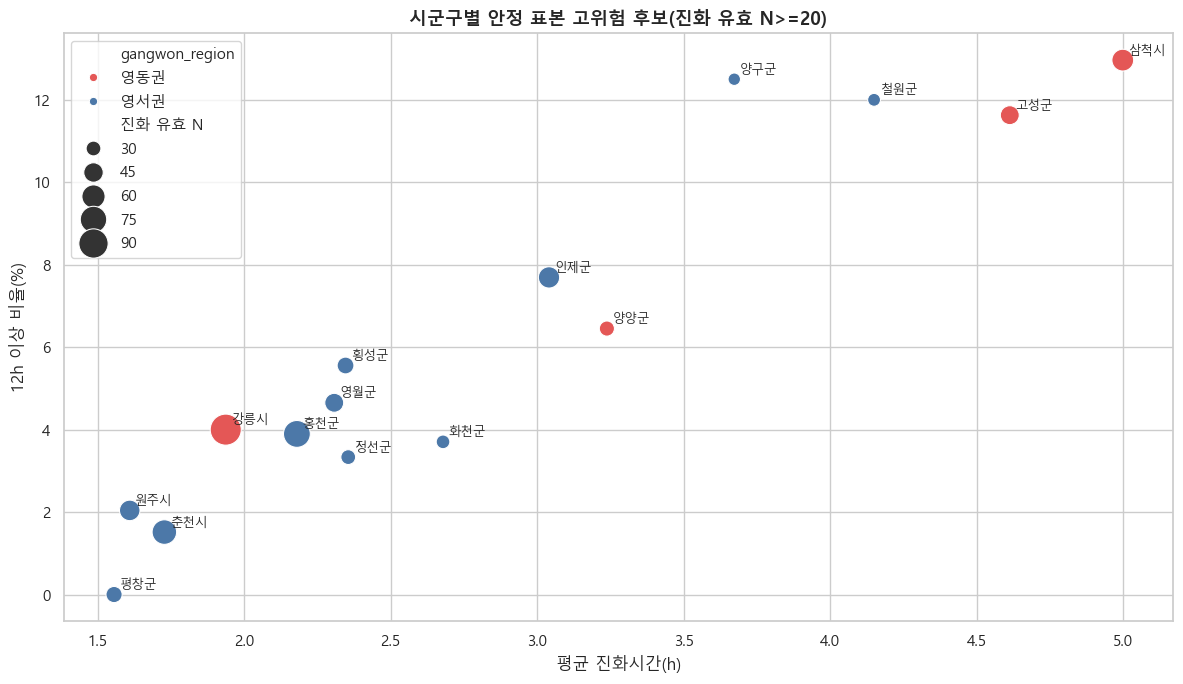

In [24]:
# 안정 표본 시군구 고위험 후보
city_summary_deep = summarize_by(gangwon_df, ['city_norm', 'gangwon_region'])
city_stable = city_summary_deep[city_summary_deep['진화 유효 N'] >= 20].sort_values('12h 이상 비율(%)', ascending=False)
print(city_stable.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 7))
sns.scatterplot(
    data=city_stable,
    x='평균 진화시간(h)',
    y='12h 이상 비율(%)',
    size='진화 유효 N',
    hue='gangwon_region',
    hue_order=REGION_ORDER,
    sizes=(80, 500),
    palette=REGION_PALETTE,
    ax=ax
)
for _, row in city_stable.iterrows():
    ax.annotate(row['city_norm'], (row['평균 진화시간(h)'], row['12h 이상 비율(%)']), xytext=(4, 4), textcoords='offset points', fontsize=9)
ax.set_title('시군구별 안정 표본 고위험 후보(진화 유효 N>=20)', fontsize=13, fontweight='bold')
ax.set_xlabel('평균 진화시간(h)')
ax.set_ylabel('12h 이상 비율(%)')
plt.tight_layout()
plt.show()


<!-- gangwon-spatial-deep-analysis:stable-city -->

**결과 및 플롯 이미지 분석**

- 안정 표본 기준에서 우상단 고위험 후보는 **삼척시, 고성군, 철원군, 양구군**이다. 삼척시와 고성군은 영동권 양간지풍·동해안 유형, 철원군과 양구군은 북부 내륙형 예외 유형으로 분리해 보는 것이 좋다.
- 삼척시는 평균 진화시간 **5.00h**, 12h 이상 비율 **12.96%**로 가장 강한 안정 후보다. 고성군도 **4.61h**, **11.63%**로 높다.
- 양구군과 철원군은 영서권인데도 12h 이상 비율이 각각 **12.50%**, **12.00%**다. 이 둘은 영동권 플래그로 잡히지 않는 고위험 지점이므로, 모델에 시군구 또는 북부 내륙 권역성 피처가 필요할 수 있다.
- 강릉시는 표본과 진화 유효 N은 크지만 12h 이상 비율은 **4.00%**로 상대적으로 낮다. 강릉은 빈도 중심 위험, 삼척·고성은 장기 진화 중심 위험으로 구분하는 것이 적절하다.


## 11. 피해면적 아웃라이어 민감도

영동권 피해면적 평균이 매우 큰 이유가 일반적 분포 차이인지, 소수 대형 산불 아웃라이어 때문인지 확인한다.
피해면적은 평균, 중앙값, P95, 상위 1% 제거 평균, 상위 피해 사건 목록을 함께 본다.


 권역  전체 N  피해면적 평균(ha)  피해면적 중앙값(ha)  피해면적 P95(ha)  피해면적 P99(ha)  상위1% 제거 평균(ha)  상위5건 피해 합계(ha)  상위5건 피해 비중(%)
영동권  1609      16.2665           0.0           0.7       29.8808          0.1949        22356.30        85.4181
영서권  2530       0.3745           0.0           0.5        2.5000          0.0588          654.31        69.0659

--- 피해면적 상위 12건 ---
 fire_id   연도  월  일  시간 city_norm gangwon_region  피해면적(ha)  진화소요시간(HH) aspect_group access_grade_gw  nearest_station_dist_km  nearest_water_dist_km  nearest_road_dist_km nearest_facility_remote
F_007042 2000  4  7  10       삼척시            영동권  13343.00     19.0000      서/남서 사면           접근 우수                   9.9168                 0.1855                1.8470                     불가능
F_007064 2000  4 12  16       삼척시            영동권   4053.40     64.8333        기타 사면           접근 취약                   9.5033                 1.7628                3.8567                     불가능
F_007063 2000  4 12   9       동해시            영동권   2243.90   

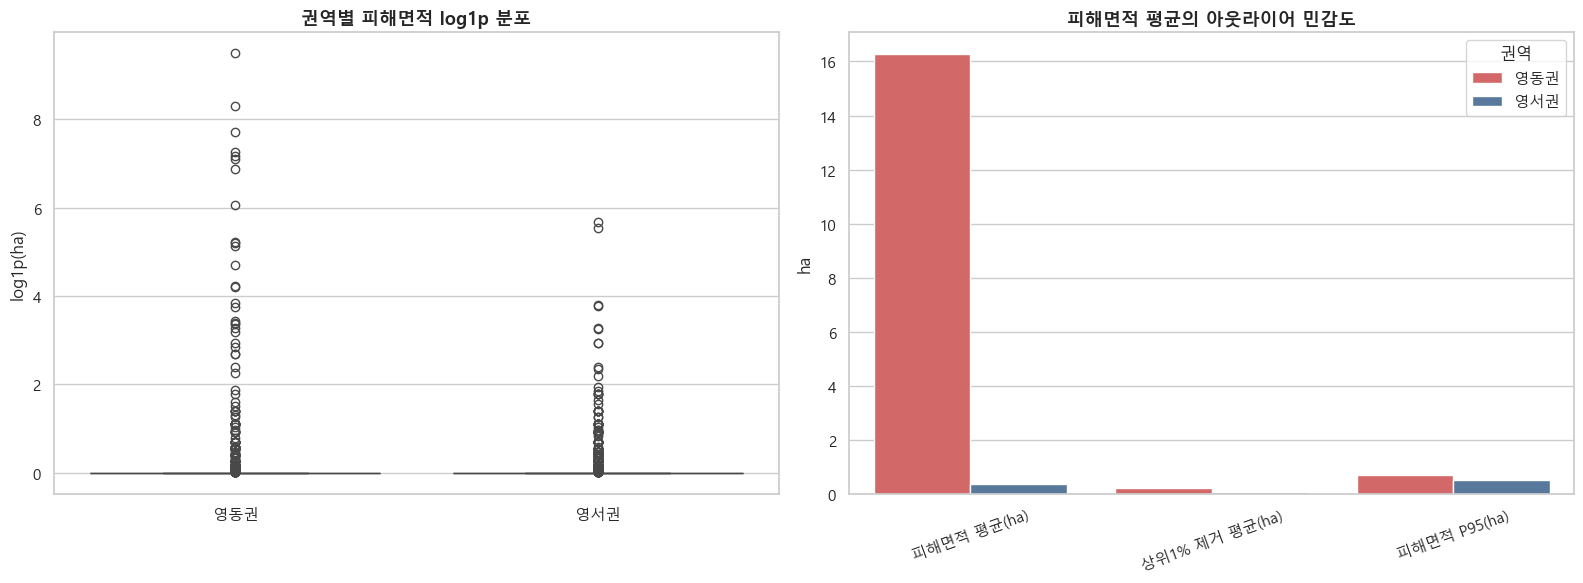

In [25]:
# 피해면적 아웃라이어 민감도
damage_rows = []
for region, g in gangwon_df.groupby('gangwon_region'):
    top1_cut = g['_damage_ha'].quantile(0.99)
    trimmed = g[g['_damage_ha'] <= top1_cut]
    top5 = g.nlargest(5, '_damage_ha')
    damage_rows.append({
        '권역': region,
        '전체 N': len(g),
        '피해면적 평균(ha)': g['_damage_ha'].mean(),
        '피해면적 중앙값(ha)': g['_damage_ha'].median(),
        '피해면적 P95(ha)': g['_damage_ha'].quantile(0.95),
        '피해면적 P99(ha)': top1_cut,
        '상위1% 제거 평균(ha)': trimmed['_damage_ha'].mean(),
        '상위5건 피해 합계(ha)': top5['_damage_ha'].sum(),
        '상위5건 피해 비중(%)': top5['_damage_ha'].sum() / g['_damage_ha'].sum() * 100 if g['_damage_ha'].sum() > 0 else np.nan,
    })

damage_sensitivity = pd.DataFrame(damage_rows).set_index('권역').reindex(REGION_ORDER).reset_index()
print(damage_sensitivity.round(4).to_string(index=False))

print('\n--- 피해면적 상위 12건 ---')
top_damage_cols = [
    'fire_id', '연도', '월', '일', '시간', 'city_norm', 'gangwon_region',
    '피해면적(ha)', '진화소요시간(HH)', 'aspect_group', 'access_grade_gw',
    'nearest_station_dist_km', 'nearest_water_dist_km', 'nearest_road_dist_km',
    'nearest_facility_remote',
]
print(gangwon_df.sort_values('_damage_ha', ascending=False)[top_damage_cols].head(12).round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
damage_plot = gangwon_df.copy()
damage_plot['피해면적_log1p'] = np.log1p(damage_plot['_damage_ha'].clip(lower=0))
sns.boxplot(
    data=damage_plot,
    x='gangwon_region', y='피해면적_log1p', hue='gangwon_region',
    order=REGION_ORDER, hue_order=REGION_ORDER,
    palette=REGION_PALETTE, legend=False, ax=axes[0], showfliers=True
)
axes[0].set_title('권역별 피해면적 log1p 분포', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('log1p(ha)')

damage_melt = damage_sensitivity.melt(
    id_vars='권역',
    value_vars=['피해면적 평균(ha)', '상위1% 제거 평균(ha)', '피해면적 P95(ha)'],
    var_name='지표',
    value_name='값'
)
sns.barplot(
    data=damage_melt,
    x='지표', y='값', hue='권역',
    hue_order=REGION_ORDER, palette=REGION_PALETTE, ax=axes[1]
)
axes[1].set_title('피해면적 평균의 아웃라이어 민감도', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('ha')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()


<!-- gangwon-spatial-deep-analysis:damage-outlier -->

**결과 및 플롯 이미지 분석**

- 영동권 피해면적 평균 **16.27ha**는 일반적 사건의 크기라기보다 소수 초대형 산불에 의해 만들어진 값이다. 영동권 피해면적 중앙값은 **0ha**, P95도 **0.7ha**에 불과하다.
- 상위 1%를 제거하면 영동권 평균 피해면적은 **0.19ha**까지 떨어진다. 상위 5건이 영동권 전체 피해면적의 **85.42%**를 차지한다.
- 피해면적 상위 사건은 2000년 4월 삼척·동해·고성·강릉, 2005년 4월 양양 등 봄철 영동권 대형 산불에 집중되어 있다. 이들은 대부분 장시간 진화와 연결되지만, 피해면적 평균 자체를 일반 사건에 대한 모델 타깃으로 쓰면 아웃라이어 지배가 매우 강하다.
- 모델링에서는 피해면적 회귀보다 `10ha 이상`, `12h 이상`, 또는 로그 변환/상위 절단을 고려하는 것이 안전하다. 특히 공간 피처 해석에서는 평균 피해면적보다 P95, 대형 산불 여부, 장기 진화 여부를 우선 보는 편이 낫다.


## 12. 강원도 공간 심화 EDA 정리

- `영동권 × 서/남서 사면 × 접근취약 × 원격제어 불가능` 조합은 평균 진화시간과 12h 이상 비율을 단계적으로 끌어올리는 강한 후보 신호다.
- 다만 최종 조합의 진화 유효 N은 26건으로 작으므로, 이 조합을 단독 규칙으로 확정하기보다 모델링 상호작용 후보로 남긴다.
- 안정 표본 기준 시군구 고위험 후보는 영동권의 **삼척시·고성군**, 영서권 예외 유형의 **철원군·양구군**이다. 강릉시는 빈도는 높지만 장기 진화율은 상대적으로 낮아 위험 유형이 다르다.
- 봄철 영동권은 평균 진화시간이 뚜렷하게 길고, 피해면적 상위 사건도 봄철 영동권에 집중된다. 공간 피처는 봄철·강풍·저습 기상 피처와 결합할 때 의미가 커질 가능성이 높다.
- 피해면적 평균은 극소수 대형 산불에 매우 민감하다. 모델링 타깃은 `12h 이상 진화`, `10ha 이상 피해`, 로그 피해면적 등으로 나누어 검토하는 편이 안전하다.
- 다음 모델링 피처 후보: `gangwon_region`, `aspect_group`, `access_grade_gw`, `access_burden_gw`, `remote_unavailable`, `spring`, `dry_season`, 그리고 `영동권×서/남서`, `영동권×접근취약`, `영동권×서/남서×접근취약` 상호작용.
